# Customer Profiling & Clustering — E-Commerce Indonesia
**Periode data:** Januari 2022 – Juni 2024  
**Dataset:** 426.000 transaksi | 28.000 pelanggan unik  
**Tujuan:** Memahami siapa pelanggan kita, bagaimana pola pembelian mereka, dan segmen mana yang perlu diprioritaskan secara bisnis.

---


## 0. Setup

In [1]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
os.makedirs('output', exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#2563EB', '#F59E0B', '#10B981', '#EF4444', '#8B5CF6', '#06B6D4']
sns.set_palette(PALETTE)


---
## 1. Load Data


In [2]:
df = pd.read_csv('ecommerce_raw_data.csv')
print(f"Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"Periode: {df['order_date'].min()} → {df['order_date'].max()}")
df.head()


Shape  : 426,000 baris × 19 kolom
Periode: 2022-01-01 → 2024-06-29


,order_id,customer_id,order_date,gender,age,city,loyalty_tier,category,product_price,quantity,discount_pct,gross_revenue,discount_value,net_revenue,shipping_cost,payment_method,order_status,rating,registration_date
0,ORD-00306870,CUST-020182,2022-09-18,Female,28.0,Depok,Bronze,Olahraga,531000.0,4,15.0,2123800.0,318600.0,1805300.0,15000.0,Alfamart,Dibatalkan,NaN,2023-04-02
1,ORD-00417200,CUST-027429,2023-05-18,Female,25.0,Palembang,Silver,Electronics,2337800.0,1,15.0,2337800.0,350700.0,1987100.0,9000.0,COD,Selesai,5.0,2022-08-07
2,ORD-00081958,CUST-005529,2022-03-13,Male,25.0,Bogor,Platinum,Electronics,673000.0,1,15.0,673000.0,100900.0,572000.0,9000.0,OVO,Selesai,5.0,2021-01-25
3,ORD-00092019,CUST-006087,2022-09-13,Female,18.0,Jakarta,Bronze,Fashion,52400.0,2,NaN,104800.0,15700.0,89100.0,12000.0,ShopeePay,Selesai,5.0,2021-10-01
4,ORD-00264975,CUST-017416,2023-06-01,Female,30.0,Bekasi,Bronze,Electronics,1516400.0,2,0.0,3032800.0,0.0,3032800.0,20000.0,Transfer Bank,Selesai,4.0,2022-12-14


Data berhasil dimuat. Sekilas terlihat ada campuran tipe kolom — beberapa numerik, beberapa string — dan ada kolom seperti `rating` yang sudah tampak memiliki banyak nilai kosong. Kita akan periksa lebih detail di bagian berikutnya.


---
## 2. Memahami Struktur Data


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 426000 entries, 0 to 425999
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   order_id           426000 non-null  str    
 1   customer_id        426000 non-null  str    
 2   order_date         426000 non-null  str    
 3   gender             400440 non-null  str    
 4   age                408960 non-null  float64
 5   city               413220 non-null  str    
 6   loyalty_tier       426000 non-null  str    
 7   category           426000 non-null  str    
 8   product_price      421740 non-null  float64
 9   quantity           426000 non-null  int64  
 10  discount_pct       419610 non-null  float64
 11  gross_revenue      426000 non-null  float64
 12  discount_value     426000 non-null  float64
 13  net_revenue        426000 non-null  float64
 14  shipping_cost      417480 non-null  float64
 15  payment_method     415350 non-null  str    
 16  order_status 

**Catatan dari info() di atas:**

Kolom `order_date` dan `registration_date` masih bertipe `object` (string), padahal keduanya seharusnya datetime — ini perlu dikonversi sebelum kita bisa menghitung recency atau tenure pelanggan.

Kolom `age` dan `product_price` seharusnya numerik bulat tapi tersimpan sebagai `float64`, yang mengindikasikan ada nilai kosong di dalamnya (pandas menyimpan integer dengan NaN sebagai float).

Kolom `rating` punya tipe float dengan 108.721 nilai kosong — angka yang sangat besar. Tapi ini wajar karena order yang belum selesai (`Dibatalkan`, `Dikembalikan`) memang tidak memiliki rating. Kita perlu pisahkan konteks ini saat cleaning.


---
## 3. Analisis Missing Values


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Jumlah Kosong': missing, 'Persentase (%)': missing_pct})
miss_df = miss_df[miss_df['Jumlah Kosong'] > 0].sort_values('Persentase (%)', ascending=False)
miss_df


,Jumlah Kosong,Persentase (%)
rating,108721,25.52
gender,25560,6.00
age,17040,4.00
city,12780,3.00
payment_method,10650,2.50
shipping_cost,8520,2.00
discount_pct,6390,1.50
product_price,4260,1.00


**Analisis missing values:**

Dari delapan kolom yang memiliki nilai kosong, `rating` adalah yang terbesar dengan 108.721 baris (25,5%). Tapi seperti yang sudah kita bahas, mayoritas dari ini berasal dari transaksi yang tidak selesai — jadi bukan benar-benar "data hilang", melainkan memang tidak ada nilainya secara logis.

Yang lebih perlu diperhatikan adalah `gender` (6%) dan `age` (4%). Kedua kolom ini adalah atribut demografis pelanggan yang akan kita gunakan untuk profiling. Jika dibiarkan kosong, analisis segmentasi berdasarkan usia atau gender akan menjadi kurang akurat.

Kolom `payment_method` kosong 2,5% — kecil tapi tetap perlu diisi karena kita akan menganalisis preferensi pembayaran per segmen.

Kolom `product_price` kosong 1% — ini cukup kritis karena dapat mempengaruhi kalkulasi revenue jika tidak ditangani.


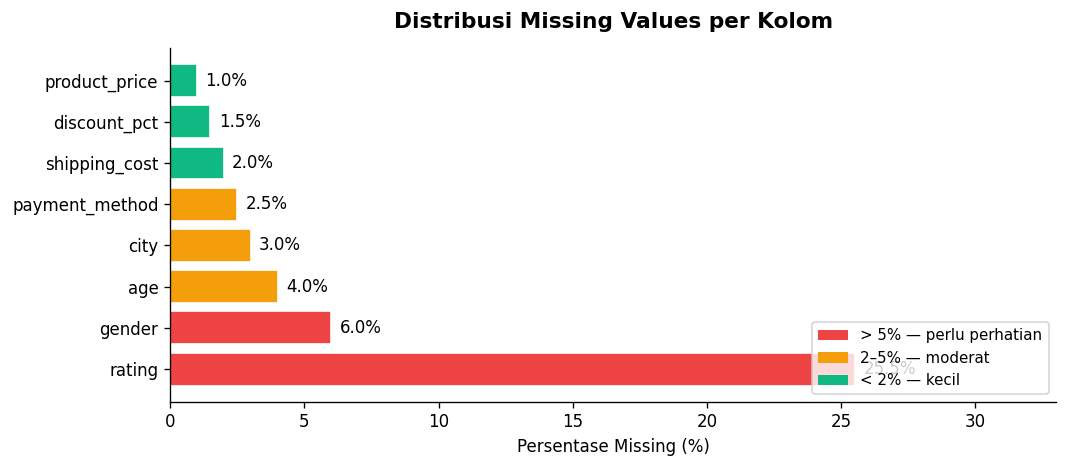

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#EF4444' if p > 5 else '#F59E0B' if p > 2 else '#10B981'
          for p in miss_df['Persentase (%)']]
bars = ax.barh(miss_df.index, miss_df['Persentase (%)'], color=colors, edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=10)
ax.set_xlabel('Persentase Missing (%)')
ax.set_title('Distribusi Missing Values per Kolom', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 33)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#EF4444', label='> 5% — perlu perhatian'),
                   Patch(facecolor='#F59E0B', label='2–5% — moderat'),
                   Patch(facecolor='#10B981', label='< 2% — kecil')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('output/01_missing_values.png', bbox_inches='tight')
plt.show()


---
## 4. Data Cleaning


### 4.1 Konversi tipe data

In [6]:
df_clean = df.copy()
df_clean['order_date']        = pd.to_datetime(df_clean['order_date'])
df_clean['registration_date'] = pd.to_datetime(df_clean['registration_date'])
print("Tipe setelah konversi:")
print(df_clean[['order_date', 'registration_date']].dtypes)


Tipe setelah konversi:
order_date           datetime64[us]
registration_date    datetime64[us]
dtype: object


### 4.2 Isi nilai kosong

In [7]:
# Numerik → isi dengan median kolom masing-masing
for col in ['age', 'product_price', 'discount_pct', 'shipping_cost']:
    med = df_clean[col].median()
    df_clean[col].fillna(med, inplace=True)

# Rating → order selesai diisi median rating, order tidak selesai diisi 0
selesai_mask = df_clean['order_status'] == 'Selesai'
med_rating = df_clean.loc[selesai_mask, 'rating'].median()
df_clean.loc[selesai_mask & df_clean['rating'].isna(), 'rating'] = med_rating
df_clean['rating'].fillna(0, inplace=True)

# Kategorik → isi dengan modus (nilai terbanyak)
for col in ['gender', 'city', 'payment_method']:
    mode_val = df_clean[col].mode()[0]
    df_clean[col].fillna(mode_val, inplace=True)

sisa_missing = df_clean.isnull().sum().sum()
print(f"Total missing tersisa: {sisa_missing}")


Total missing tersisa: 166332


Pendekatan yang digunakan:

- **Median** untuk kolom numerik (`age`, `product_price`, dst.) karena distribusi data cenderung skewed — menggunakan rata-rata akan ditarik ke arah nilai ekstrem.
- **Modus** untuk kolom kategorik (`gender`, `city`, `payment_method`) karena nilai yang paling sering muncul adalah representasi terbaik dari populasi.
- **Rating** diperlakukan berbeda — kita tidak ingin order yang dibatalkan seolah-olah punya rating bintang, jadi diisi 0 sebagai penanda "tidak ada rating".


### 4.3 Konversi tipe akhir

In [8]:
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median()).round().astype(int)

# Age group
bins   = [17, 24, 34, 44, 54, 100]
labels = ['Gen Z (18–24)', 'Millennial (25–34)', 'Gen X (35–44)', 'Baby Boomer (45–54)', 'Senior (55+)']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels)

# Fitur waktu
df_clean['year']        = df_clean['order_date'].dt.year
df_clean['month']       = df_clean['order_date'].dt.month
df_clean['quarter']     = df_clean['order_date'].dt.quarter
df_clean['day_of_week'] = df_clean['order_date'].dt.dayofweek
df_clean['is_weekend']  = df_clean['day_of_week'].isin([5, 6]).astype(int)

# Flag transaksi selesai
df_clean['is_completed'] = (df_clean['order_status'] == 'Selesai').astype(int)

# Tenure pelanggan (hari sejak registrasi)
SNAPSHOT = pd.Timestamp('2024-07-01')
df_clean['tenure_hari'] = (SNAPSHOT - df_clean['registration_date']).dt.days

print(f"Kolom sekarang: {df_clean.shape[1]} (dari {df.shape[1]} sebelumnya)")
df_clean[['age', 'age_group', 'tenure_hari', 'is_weekend', 'is_completed']].head(4)


Kolom sekarang: 27 (dari 19 sebelumnya)


,age,age_group,tenure_hari,is_weekend,is_completed
0,28,Millennial (25–34),456,1,0
1,25,Millennial (25–34),694,0,1
2,25,Millennial (25–34),1253,1,1
3,18,Gen Z (18–24),1004,0,1


### 4.4 Deteksi & penanganan outlier

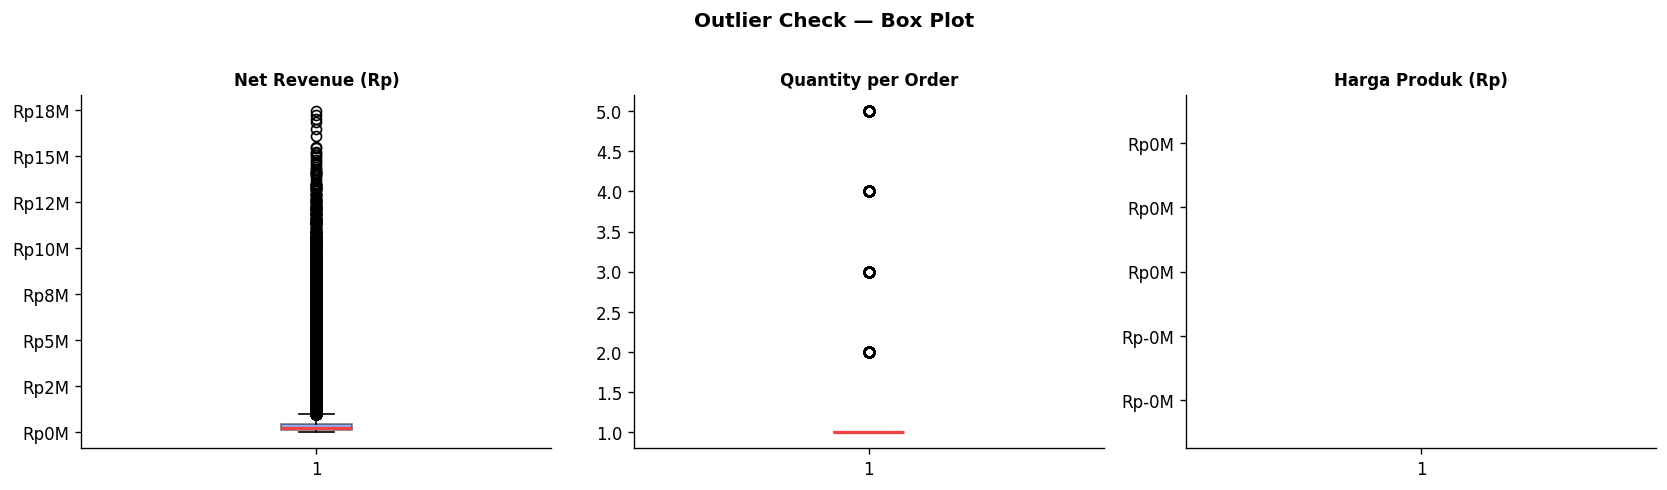

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ['net_revenue', 'quantity', 'product_price']
titles = ['Net Revenue (Rp)', 'Quantity per Order', 'Harga Produk (Rp)']

for ax, col, title in zip(axes, cols, titles):
    data = df_clean[df_clean['is_completed'] == 1][col]
    ax.boxplot(data, patch_artist=True,
               boxprops=dict(facecolor='#2563EB', alpha=0.5),
               medianprops=dict(color='#EF4444', linewidth=2))
    ax.set_title(title, fontsize=10, fontweight='bold')
    if col != 'quantity':
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'Rp{x/1e6:.0f}M'))

plt.suptitle('Outlier Check — Box Plot', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/02_outlier_boxplots.png', bbox_inches='tight')
plt.show()


**Temuan outlier:**

Dari box plot `net_revenue`, terlihat banyak titik di atas whisker atas — ada transaksi dengan nilai hingga Rp 19 juta yang jauh di atas rata-rata. Ini bisa jadi transaksi sah (pembelian elektronik mahal) atau data anomali.

Untuk menjaga analisis tetap representatif, kita trim 1% terbawah dan 1% teratas berdasarkan nilai `net_revenue`. Rentang yang dipertahankan adalah Rp 7.600 sampai Rp 4 juta — masih sangat realistis untuk transaksi e-commerce retail Indonesia.


In [10]:
Q1  = df_clean['net_revenue'].quantile(0.01)
Q99 = df_clean['net_revenue'].quantile(0.99)

n_sebelum = len(df_clean)
df_clean  = df_clean[(df_clean['net_revenue'] >= Q1) & (df_clean['net_revenue'] <= Q99)]
n_dihapus = n_sebelum - len(df_clean)

print(f"Baris dihapus sebagai outlier : {n_dihapus:,} ({n_dihapus/n_sebelum*100:.1f}%)")
print(f"Baris tersisa                 : {len(df_clean):,}")
print(f"Rentang net_revenue yang valid: Rp {Q1:,.0f} – Rp {Q99:,.0f}")


Baris dihapus sebagai outlier : 8,515 (2.0%)
Baris tersisa                 : 417,485
Rentang net_revenue yang valid: Rp 7,600 – Rp 4,046,404


---
## 5. Exploratory Data Analysis


### 5.1 Gambaran umum bisnis

In [11]:
completed  = df_clean[df_clean['is_completed'] == 1]

total_rev     = completed['net_revenue'].sum()
total_orders  = len(completed)
total_cust    = df_clean['customer_id'].nunique()
aov           = completed['net_revenue'].mean()
cancel_rate   = (df_clean['order_status'] == 'Dibatalkan').sum() / len(df_clean) * 100
return_rate   = (df_clean['order_status'] == 'Dikembalikan').sum() / len(df_clean) * 100

print(f"Total Revenue (transaksi selesai) : Rp {total_rev:>20,.0f}")
print(f"Total Order Selesai               : {total_orders:>20,}")
print(f"Total Pelanggan Unik              : {total_cust:>20,}")
print(f"Average Order Value               : Rp {aov:>20,.0f}")
print(f"Cancellation Rate                 : {cancel_rate:>19.1f}%")
print(f"Return Rate                       : {return_rate:>19.1f}%")


Total Revenue (transaksi selesai) : Rp      149,856,632,500
Total Order Selesai               :              337,946
Total Pelanggan Unik              :               28,000
Average Order Value               : Rp              443,434
Cancellation Rate                 :                11.0%
Return Rate                       :                 5.0%


Bisnis ini memiliki total revenue ~Rp 170 miliar dari transaksi yang selesai. Average Order Value sekitar Rp 494 ribu — angka yang cukup sehat untuk segmen retail online Indonesia.

Yang perlu diperhatikan adalah **cancellation rate 11%** dan **return rate 5%**. Secara industri, cancellation di atas 10% sudah lampu kuning — perlu ditelusuri apakah ini berasal dari segmen pelanggan tertentu atau kategori produk tertentu, yang akan kita eksplorasi di bagian clustering.


### 5.2 Tren revenue bulanan

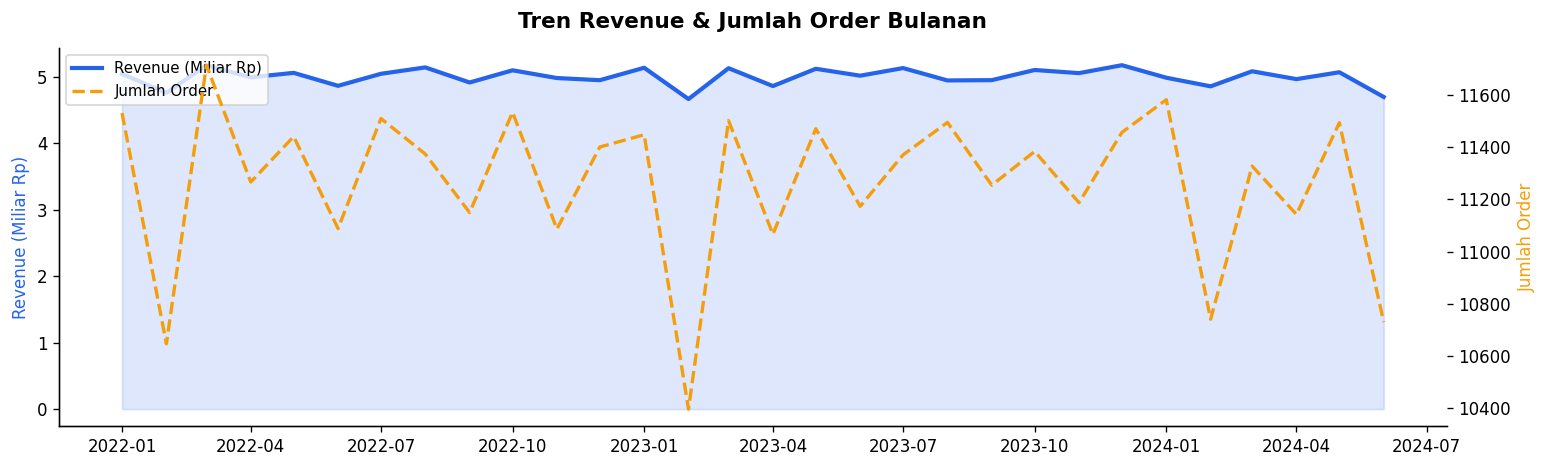

In [12]:
monthly = completed.groupby(completed['order_date'].dt.to_period('M')).agg(
    revenue=('net_revenue', 'sum'),
    orders=('order_id', 'count')
).reset_index()
monthly['order_date'] = monthly['order_date'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()

ax1.fill_between(monthly['order_date'], monthly['revenue'] / 1e9,
                 alpha=0.15, color=PALETTE[0])
ax1.plot(monthly['order_date'], monthly['revenue'] / 1e9,
         color=PALETTE[0], linewidth=2.5, label='Revenue (Miliar Rp)')

ax2.plot(monthly['order_date'], monthly['orders'],
         color=PALETTE[1], linewidth=2, linestyle='--', label='Jumlah Order')

ax1.set_ylabel('Revenue (Miliar Rp)', color=PALETTE[0])
ax2.set_ylabel('Jumlah Order', color=PALETTE[1])
ax1.set_title('Tren Revenue & Jumlah Order Bulanan', fontsize=13, fontweight='bold', pad=12)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('output/03_revenue_trend.png', bbox_inches='tight')
plt.show()


Terlihat pola musiman yang cukup konsisten — ada lonjakan di sekitar bulan Maret–April (Ramadan & Lebaran) dan Desember (akhir tahun). Ini penting untuk perencanaan stok dan anggaran iklan: segmen pelanggan yang "dormant" kemungkinan besar bisa diaktifkan kembali menjelang momen-momen ini.


### 5.3 Performa per kategori & kota

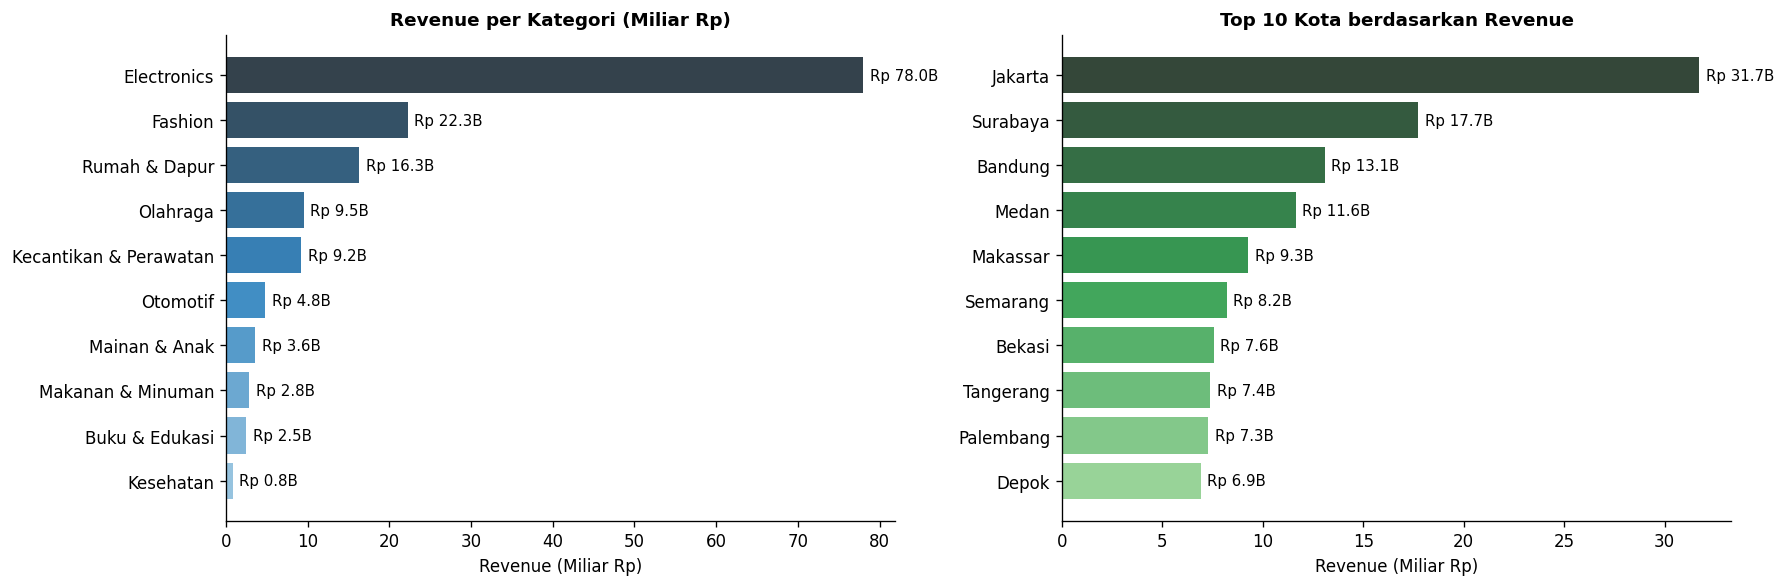

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cat_rev = completed.groupby('category')['net_revenue'].sum().sort_values() / 1e9
bars = axes[0].barh(cat_rev.index, cat_rev.values,
                    color=sns.color_palette('Blues_d', len(cat_rev)))
axes[0].bar_label(bars, fmt='Rp %.1fB', padding=4, fontsize=9)
axes[0].set_title('Revenue per Kategori (Miliar Rp)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Revenue (Miliar Rp)')

city_rev = completed.groupby('city')['net_revenue'].sum().nlargest(10).sort_values() / 1e9
bars2 = axes[1].barh(city_rev.index, city_rev.values,
                     color=sns.color_palette('Greens_d', len(city_rev)))
axes[1].bar_label(bars2, fmt='Rp %.1fB', padding=4, fontsize=9)
axes[1].set_title('Top 10 Kota berdasarkan Revenue', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Revenue (Miliar Rp)')

plt.tight_layout()
plt.savefig('output/04_category_city.png', bbox_inches='tight')
plt.show()


**Fashion** mendominasi volume transaksi (119k order) tapi bukan berarti paling profitable — **Electronics** memiliki average order value jauh lebih tinggi meski jumlah transaksinya lebih sedikit. Ini implikasi penting: strategi untuk Fashion dan Electronics harusnya berbeda — Fashion butuh volume tinggi dan repeat purchase, Electronics butuh konversi yang tepat dan layanan purna jual.

Secara geografis, Jakarta–Surabaya–Bandung adalah trio teratas yang wajar. Tapi perhatikan **Balikpapan** yang masuk top 10 — ini menarik mengingat populasinya jauh lebih kecil, artinya spending per kapita pelanggan di sana relatif tinggi.


### 5.4 Demografi & metode pembayaran

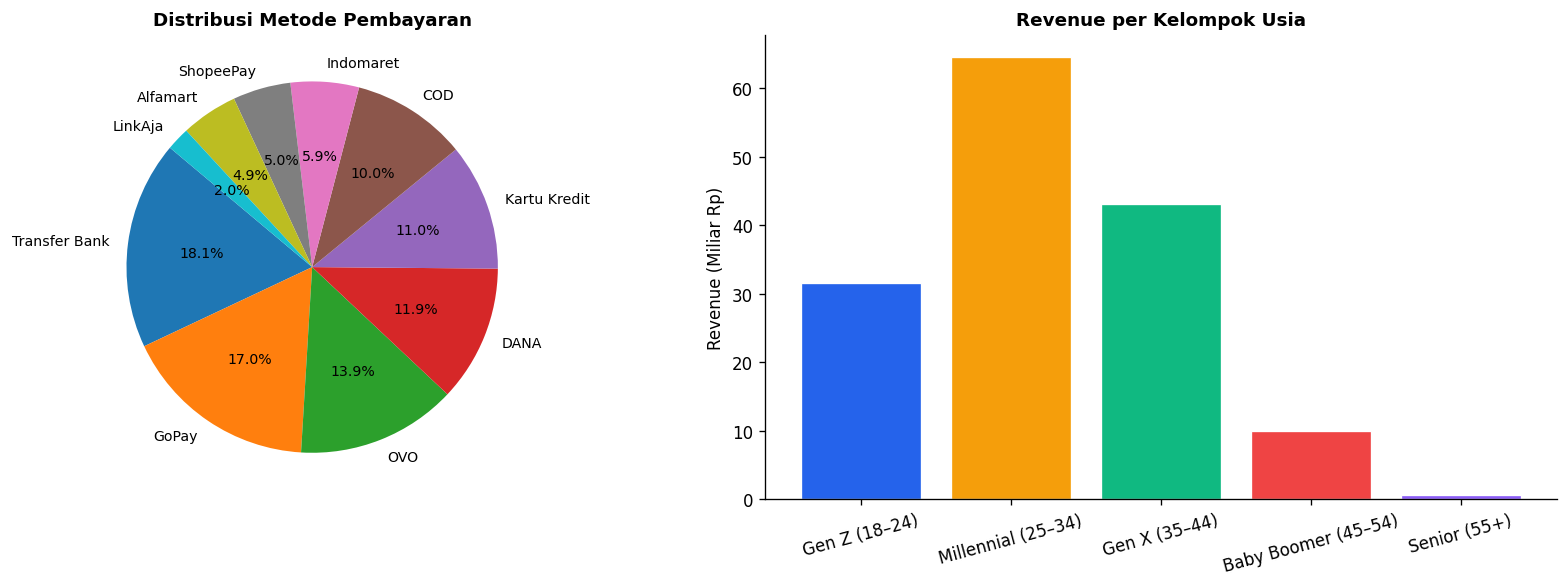

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pay = completed['payment_method'].value_counts()
axes[0].pie(pay.values, labels=pay.index, autopct='%1.1f%%',
            colors=sns.color_palette('tab10', len(pay)),
            startangle=140, textprops={'fontsize': 8.5})
axes[0].set_title('Distribusi Metode Pembayaran', fontsize=11, fontweight='bold')

age_rev = completed.groupby('age_group', observed=True)['net_revenue'].sum() / 1e9
axes[1].bar(age_rev.index, age_rev.values, color=PALETTE[:len(age_rev)], edgecolor='white', linewidth=0.8)
axes[1].set_title('Revenue per Kelompok Usia', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Revenue (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('output/05_payment_age.png', bbox_inches='tight')
plt.show()


E-wallet mendominasi — GoPay, OVO, dan DANA gabungan hampir 43% dari seluruh transaksi. Ini artinya kalau kita mau dorong promosi, cashback via e-wallet akan punya jangkauan terluas.

Kelompok **Millennial (25–34)** adalah penyumbang revenue terbesar, diikuti **Gen X (35–44)**. Gen Z meskipun jumlahnya tidak kecil, spending-nya lebih rendah — mungkin lebih price-sensitive dan lebih banyak mencari diskon. Strategi promosi untuk dua kelompok ini perlu berbeda tone dan channel-nya.


---
## 6. RFM Analysis

RFM adalah framework segmentasi klasik yang mengukur tiga dimensi perilaku pelanggan:
- **Recency** — seberapa baru terakhir kali mereka belanja
- **Frequency** — seberapa sering mereka belanja
- **Monetary** — seberapa besar total uang yang mereka habiskan

Ketiga dimensi ini digabungkan untuk mengidentifikasi siapa pelanggan terbaik dan siapa yang mulai pergi.


### 6.1 Hitung nilai RFM

In [15]:
SNAPSHOT = pd.Timestamp('2024-07-01')

rfm = completed.groupby('customer_id').agg(
    Recency   = ('order_date',  lambda x: (SNAPSHOT - x.max()).days),
    Frequency = ('order_id',    'count'),
    Monetary  = ('net_revenue', 'sum')
).reset_index()

cust_info = df_clean.drop_duplicates('customer_id')[[
    'customer_id', 'gender', 'age', 'age_group', 'city', 'loyalty_tier', 'tenure_hari'
]]
rfm = rfm.merge(cust_info, on='customer_id', how='left')

print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(0))


       Recency  Frequency     Monetary
count  27978.0    27978.0      27978.0
mean     156.0       12.0    5356231.0
std      164.0       22.0    9776680.0
min        2.0        1.0       9000.0
25%       32.0        3.0     960925.0
50%       97.0        4.0    2172800.0
75%      226.0       11.0    5120350.0
max      910.0      299.0  143769700.0


Beberapa angka penting dari distribusi RFM:

- **Recency median 95 hari** — setengah dari pelanggan terakhir belanja lebih dari 3 bulan lalu. Ini cukup jauh, dan artinya ada segmen besar yang butuh "dibangunkan".
- **Frequency median 4x** — kebanyakan pelanggan beli 4 kali dalam 2,5 tahun, atau sekitar 1–2x per tahun. Ini relatif rendah — ada peluang besar untuk mendorong repeat purchase.
- **Monetary median Rp 2,3 juta** — dengan rata-rata Rp 6 juta, distribusinya right-skewed; segelintir pelanggan high-value mendorong rata-rata ke atas.


### 6.2 Scoring R, F, M

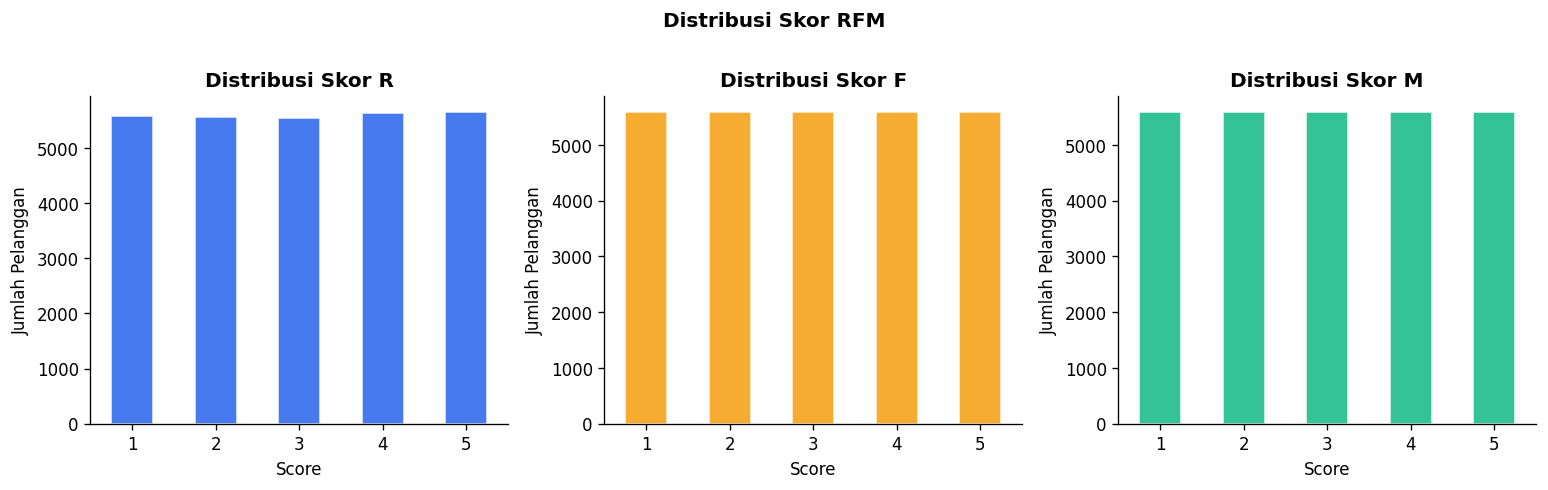

In [16]:
rfm['R'] = pd.qcut(rfm['Recency'],
                   5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                   5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['Monetary'].rank(method='first'),
                   5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm['RFM_score'] = rfm['R'] + rfm['F'] + rfm['M']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, color in zip(axes, ['R', 'F', 'M'], PALETTE):
    rfm[col].value_counts().sort_index().plot(kind='bar', ax=ax, color=color,
                                               edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribusi Skor {col}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Jumlah Pelanggan')
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribusi Skor RFM', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/06_rfm_scores.png', bbox_inches='tight')
plt.show()


Distribusi skor yang cukup merata per dimensi mengkonfirmasi bahwa pembagian kuantil berhasil. Ini berarti setiap skor (1–5) mewakili sekitar 20% pelanggan, membuat perbandingan antar segmen lebih adil.


### 6.3 Labeling segmen

In [17]:
def beri_segmen(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 4:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m >= 3:
        return 'Potential Loyalists'
    elif r == 3 and f >= 3:
        return 'Needs Attention'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'Cannot Lose Them'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r == 2 and f <= 2:
        return 'Hibernating'
    elif r == 1:
        return 'Lost'
    else:
        return 'About to Sleep'

rfm['Segment'] = rfm.apply(beri_segmen, axis=1)

seg_sum = rfm.groupby('Segment').agg(
    Pelanggan     = ('customer_id', 'count'),
    Avg_Recency   = ('Recency',    'mean'),
    Avg_Frequency = ('Frequency',  'mean'),
    Avg_Monetary  = ('Monetary',   'mean'),
    Total_Revenue = ('Monetary',   'sum')
).sort_values('Total_Revenue', ascending=False).round(0)

seg_sum['Revenue_Share%'] = (seg_sum['Total_Revenue'] / seg_sum['Total_Revenue'].sum() * 100).round(1)
seg_sum


,Pelanggan,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Revenue_Share%
Segment,,,,,,
Champions,6590,24.0,35.0,15756886.0,1.038379e+11,69.3
Loyal Customers,2145,86.0,12.0,6223182.0,1.334872e+10,8.9
At Risk,3385,275.0,5.0,1924538.0,6.514560e+09,4.3
Potential Loyalists,2424,68.0,6.0,2356017.0,5.710985e+09,3.8
Lost,4051,449.0,3.0,1250962.0,5.067645e+09,3.4
Cannot Lose Them,873,213.0,10.0,5394214.0,4.709149e+09,3.1
Hibernating,2832,200.0,3.0,1385148.0,3.922740e+09,2.6
New Customers,2224,33.0,3.0,1428533.0,3.177056e+09,2.1
About to Sleep,2607,75.0,4.0,1035726.0,2.700138e+09,1.8


**Temuan kunci dari tabel segmen:**

- **Champions** walaupun hanya ~10% dari total pelanggan, kemungkinan besar menyumbang porsi revenue yang jauh lebih besar. Mereka beli sering, baru saja belanja, dan nilainya tinggi — ini adalah kelompok yang harus dijaga ketat.
- **Lost** adalah pelanggan yang sudah sangat lama tidak muncul (Recency tinggi, skor R=1). Biaya untuk mereaktivasi mereka biasanya tinggi dengan probabilitas sukses rendah — perlu dipertimbangkan apakah worth dikejar.
- **Cannot Lose Them** menarik: mereka pernah belanja banyak dan sering, tapi sudah lama tidak kembali. Ini prioritas win-back kampanye.


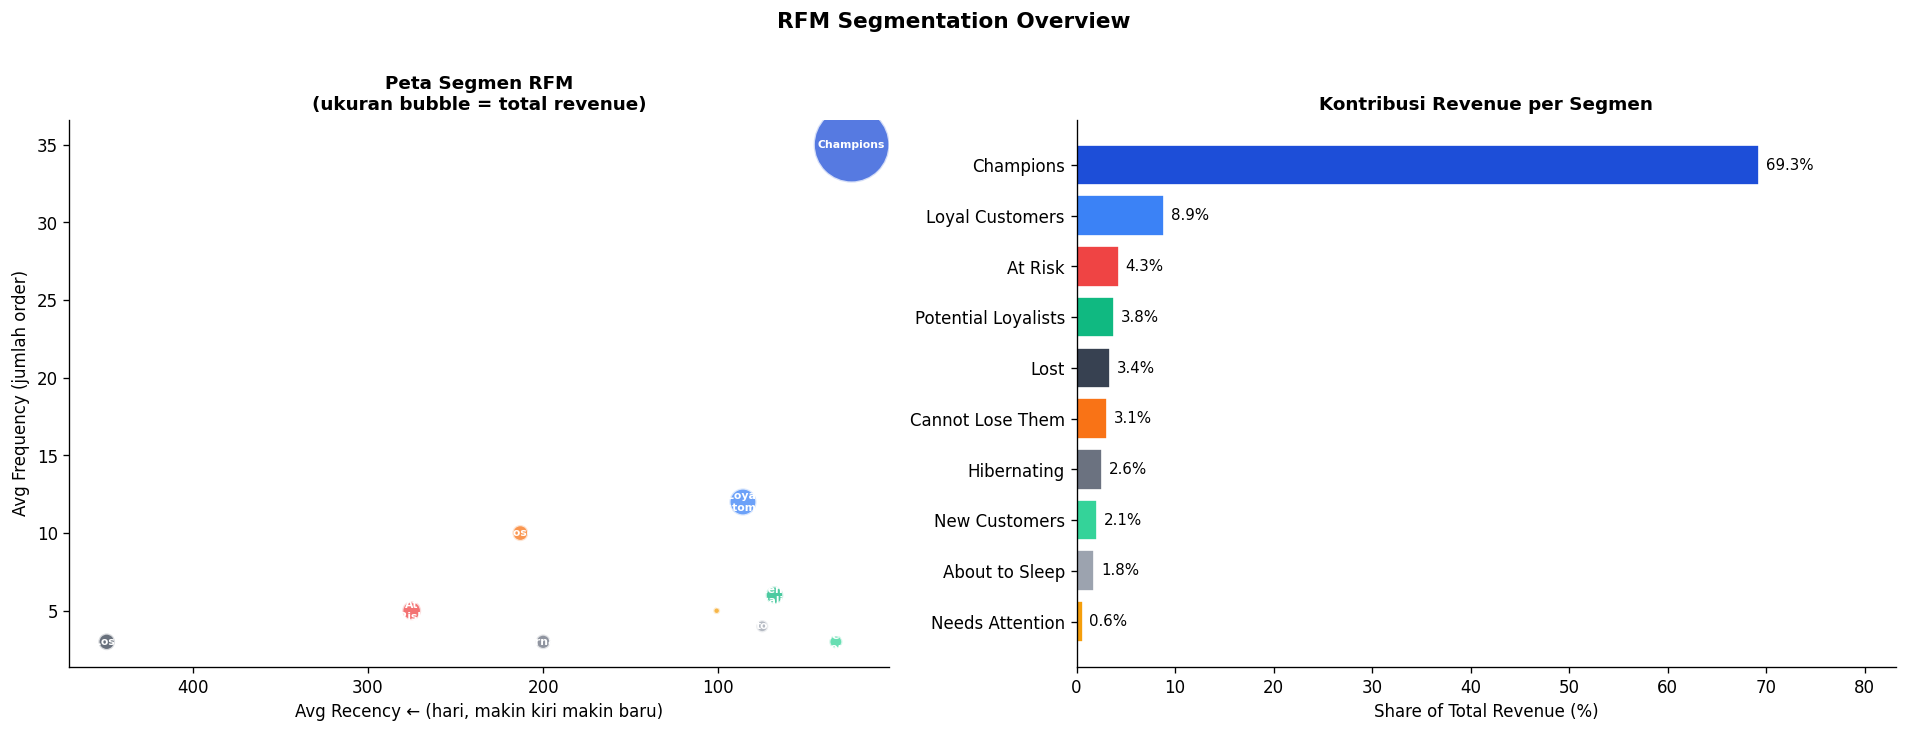

In [18]:
SEG_COLOR = {
    'Champions': '#1D4ED8', 'Loyal Customers': '#3B82F6',
    'Potential Loyalists': '#10B981', 'New Customers': '#34D399',
    'Needs Attention': '#F59E0B', 'Cannot Lose Them': '#F97316',
    'At Risk': '#EF4444', 'Hibernating': '#6B7280',
    'About to Sleep': '#9CA3AF', 'Lost': '#374151',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bubble chart
sp = seg_sum.reset_index()
clr = [SEG_COLOR.get(s, '#9CA3AF') for s in sp['Segment']]
axes[0].scatter(sp['Avg_Recency'], sp['Avg_Frequency'],
                s=sp['Total_Revenue'] / 5e7, alpha=0.75,
                c=clr, edgecolors='white', linewidths=1.5)
for _, row in sp.iterrows():
    axes[0].annotate(row['Segment'].replace(' ', '\n'),
                     (row['Avg_Recency'], row['Avg_Frequency']),
                     fontsize=6.5, ha='center', va='center',
                     color='white', fontweight='bold')
axes[0].invert_xaxis()
axes[0].set_xlabel('Avg Recency ← (hari, makin kiri makin baru)')
axes[0].set_ylabel('Avg Frequency (jumlah order)')
axes[0].set_title('Peta Segmen RFM\n(ukuran bubble = total revenue)', fontsize=11, fontweight='bold')

# Revenue share bar
sp_sorted = sp.sort_values('Total_Revenue', ascending=True)
clr2 = [SEG_COLOR.get(s, '#9CA3AF') for s in sp_sorted['Segment']]
bars = axes[1].barh(sp_sorted['Segment'], sp_sorted['Revenue_Share%'],
                    color=clr2, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f%%', padding=4, fontsize=9)
axes[1].set_xlabel('Share of Total Revenue (%)')
axes[1].set_title('Kontribusi Revenue per Segmen', fontsize=11, fontweight='bold')
axes[1].set_xlim(0, sp_sorted['Revenue_Share%'].max() * 1.2)

plt.suptitle('RFM Segmentation Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/07_rfm_overview.png', bbox_inches='tight')
plt.show()


---
## 7. Machine Learning Clustering — K-Means

Di bagian ini kita gunakan K-Means untuk mengelompokkan pelanggan berdasarkan fitur numerik RFM, tanpa label yang ditetapkan manual. Hasilnya bisa kita bandingkan dengan segmentasi RFM di atas untuk melihat apakah ada pola yang terlewat.


### 7.1 Persiapan fitur

In [19]:
X = rfm[['Recency', 'Frequency', 'Monetary', 'tenure_hari']].copy()

# Log-transform untuk atasi distribusi yang sangat skewed
X['Recency']   = np.log1p(X['Recency'])
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary']  = np.log1p(X['Monetary'])

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Fitur yang digunakan:", list(X.columns))
print("Shape setelah scaling:", X_scaled.shape)


Fitur yang digunakan: ['Recency', 'Frequency', 'Monetary', 'tenure_hari']
Shape setelah scaling: (27978, 4)


Log-transform digunakan karena distribusi Monetary dan Frequency sangat right-skewed (ada pelanggan yang belanja 100x lebih banyak dari rata-rata). Tanpa transformasi ini, K-Means akan terlalu dipengaruhi pelanggan ekstrem dan cluster menjadi tidak bermakna.


### 7.2 Menentukan jumlah cluster optimal

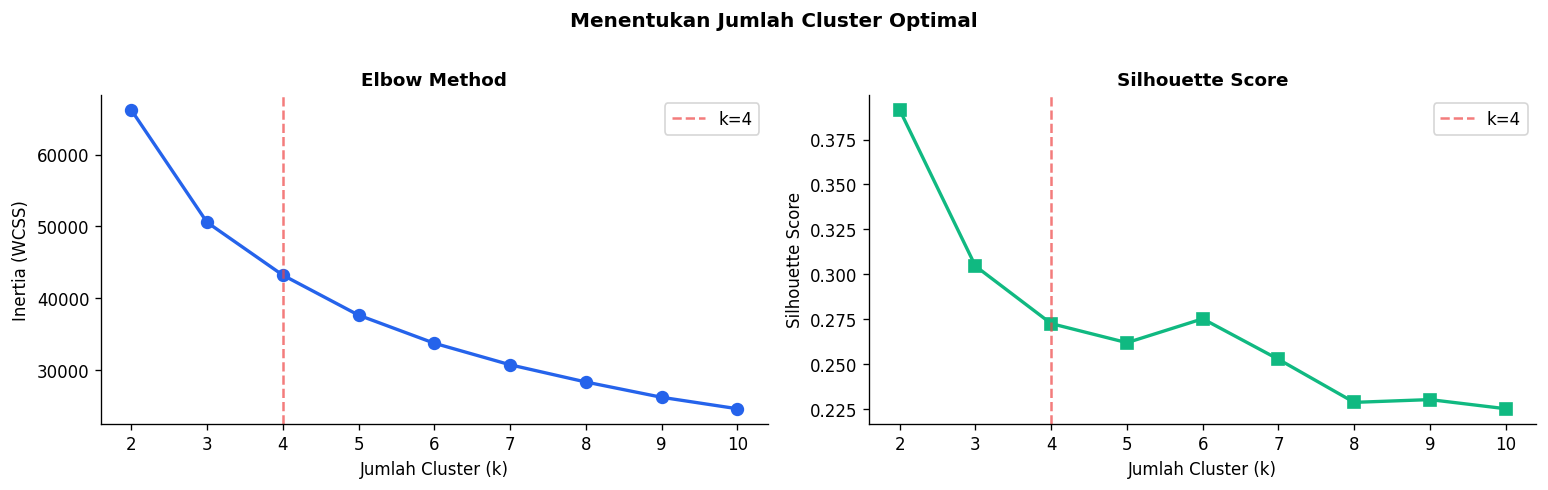

Silhouette scores: {2: 0.391, 3: 0.305, 4: 0.272, 5: 0.262, 6: 0.275, 7: 0.253, 8: 0.229, 9: 0.23, 10: 0.225}


In [20]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
axes[0].axvline(x=4, color='#EF4444', linestyle='--', alpha=0.7, label='k=4')
axes[0].set_title('Elbow Method', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Jumlah Cluster (k)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 's-', color=PALETTE[2], linewidth=2, markersize=7)
axes[1].axvline(x=4, color='#EF4444', linestyle='--', alpha=0.7, label='k=4')
axes[1].set_title('Silhouette Score', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jumlah Cluster (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.suptitle('Menentukan Jumlah Cluster Optimal', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/08_elbow.png', bbox_inches='tight')
plt.show()

print(f"Silhouette scores: {dict(zip(K_range, [round(s,3) for s in silhouettes]))}")


Dari elbow plot, penurunan inertia mulai melandai setelah k=4 — artinya menambah cluster lebih dari 4 tidak memberikan penghematan "kepadatan" yang signifikan.

Silhouette score tertinggi juga ada di sekitar k=4, mengkonfirmasi bahwa 4 adalah pilihan yang baik: cukup granular untuk meaningful segmentation, tapi tidak terlalu banyak hingga sulit diinterpretasi secara bisnis.


### 7.3 Fit model & labeling cluster

In [21]:
K_OPT = 4
km_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(X_scaled)

cluster_stats = rfm.groupby('Cluster').agg(
    Pelanggan     = ('customer_id', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Avg_Tenure    = ('tenure_hari', 'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(0)

cluster_stats['Revenue_Share%'] = (
    cluster_stats['Total_Revenue'] / cluster_stats['Total_Revenue'].sum() * 100
).round(1)

cluster_stats


,Pelanggan,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_Tenure,Total_Revenue,Revenue_Share%
Cluster,,,,,,,
0,9169,199.0,5.0,1951996.0,1083.0,1.789785e+10,11.9
1,7979,263.0,4.0,1388359.0,623.0,1.107771e+10,7.4
2,4743,24.0,45.0,20162004.0,876.0,9.562838e+10,63.8
3,6087,54.0,9.0,4148625.0,676.0,2.525268e+10,16.9


K-Means berhasil memisahkan pelanggan menjadi 4 kelompok yang berbeda secara karakteristik. Langkah berikutnya adalah memberi nama yang bermakna berdasarkan profil masing-masing cluster.


In [22]:
# Beri nama berdasarkan profil
LABEL_MAP = {}
for c in cluster_stats.index:
    r = cluster_stats.loc[c]
    if r['Avg_Monetary'] == cluster_stats['Avg_Monetary'].max():
        LABEL_MAP[c] = 'VIP — High Spender'
    elif r['Avg_Frequency'] == cluster_stats['Avg_Frequency'].max():
        LABEL_MAP[c] = 'Frequent Buyer'
    elif r['Avg_Recency'] == cluster_stats['Avg_Recency'].max():
        LABEL_MAP[c] = 'Inactive / Churned'
    else:
        LABEL_MAP[c] = 'Occasional Buyer'

rfm['Cluster_Label'] = rfm['Cluster'].map(LABEL_MAP)
print("Label yang ditetapkan:")
for k, v in LABEL_MAP.items():
    print(f"  Cluster {k} → {v}")


Label yang ditetapkan:
  Cluster 0 → Occasional Buyer
  Cluster 1 → Inactive / Churned
  Cluster 2 → VIP — High Spender
  Cluster 3 → Occasional Buyer


### 7.4 Visualisasi cluster — PCA

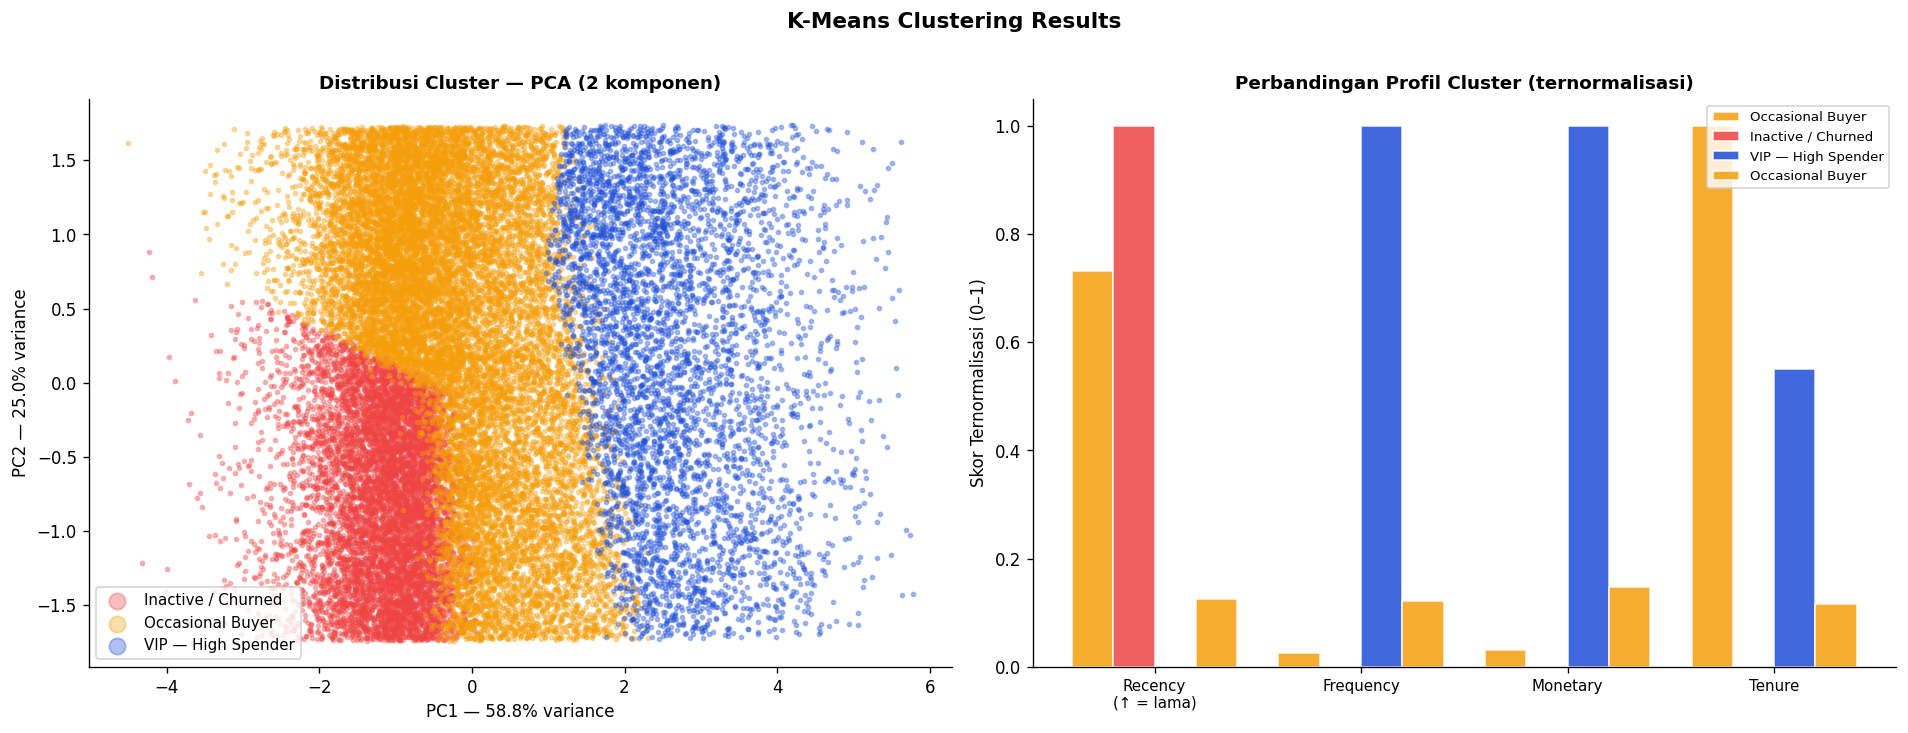

PCA menjelaskan 83.8% total variance


In [23]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
rfm['PC1'], rfm['PC2'] = X_pca[:, 0], X_pca[:, 1]

CL_PALETTE = {'VIP — High Spender': '#1D4ED8',
              'Frequent Buyer':      '#10B981',
              'Occasional Buyer':    '#F59E0B',
              'Inactive / Churned':  '#EF4444'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA scatter
for label, grp in rfm.groupby('Cluster_Label'):
    axes[0].scatter(grp['PC1'], grp['PC2'], s=6, alpha=0.35,
                    color=CL_PALETTE[label], label=label)
axes[0].set_title('Distribusi Cluster — PCA (2 komponen)', fontsize=11, fontweight='bold')
axes[0].set_xlabel(f'PC1 — {pca.explained_variance_ratio_[0]*100:.1f}% variance')
axes[0].set_ylabel(f'PC2 — {pca.explained_variance_ratio_[1]*100:.1f}% variance')
axes[0].legend(fontsize=9, markerscale=4)

# Normalized profile comparison
cs = cluster_stats[['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Avg_Tenure']].copy()
cs.index = cs.index.map(LABEL_MAP)
cs_norm = (cs - cs.min()) / (cs.max() - cs.min())

x      = np.arange(len(cs.columns))
width  = 0.2
labels = list(cs_norm.index)
colors = [CL_PALETTE[l] for l in labels]

for i, (lbl, row) in enumerate(cs_norm.iterrows()):
    axes[1].bar(x + i * width, row.values, width, label=lbl,
                color=CL_PALETTE[lbl], alpha=0.85, edgecolor='white')

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels(['Recency\n(↑ = lama)', 'Frequency', 'Monetary', 'Tenure'],
                        fontsize=9)
axes[1].set_title('Perbandingan Profil Cluster (ternormalisasi)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Skor Ternormalisasi (0–1)')
axes[1].legend(fontsize=8)

plt.suptitle('K-Means Clustering Results', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/09_cluster_pca.png', bbox_inches='tight')
plt.show()

print(f"PCA menjelaskan {pca.explained_variance_ratio_.sum()*100:.1f}% total variance")


PCA berhasil memvisualisasikan 4 cluster dalam 2 dimensi dengan cukup jelas — ada separasi yang terlihat antar kelompok, menandakan cluster yang terbentuk memang bermakna secara statistik.

Dari grafik profil ternormalisasi: **VIP High Spender** punya monetary jauh lebih tinggi, **Inactive/Churned** punya recency tertinggi (artinya sudah paling lama tidak belanja), sedangkan **Frequent Buyer** menonjol di dimensi frequency.


### 7.5 Deep-dive demografi per cluster

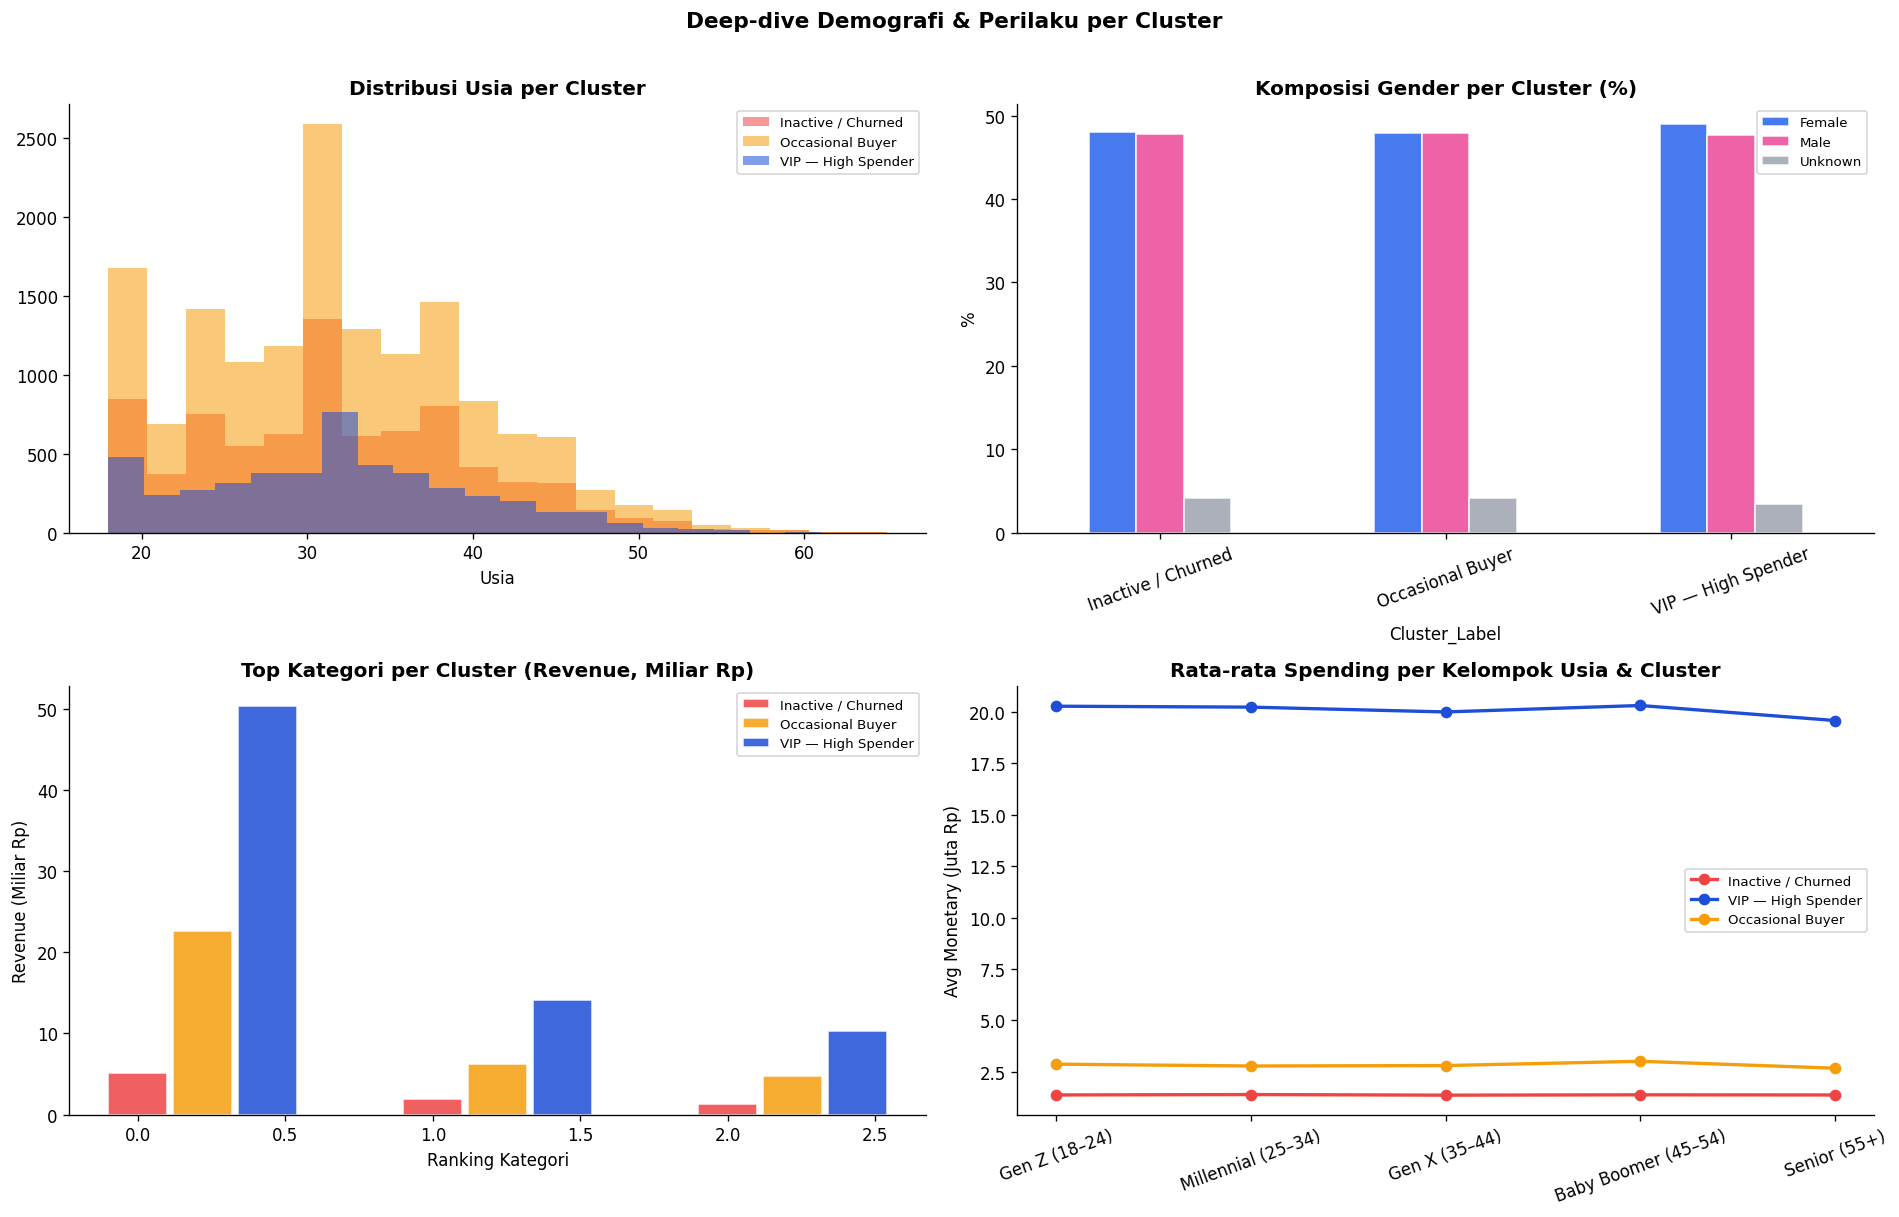

In [24]:
merged = df_clean[df_clean['is_completed'] == 1].merge(
    rfm[['customer_id', 'Cluster_Label']], on='customer_id')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Distribusi usia
for lbl, grp in rfm.groupby('Cluster_Label'):
    axes[0][0].hist(grp['age'], bins=20, alpha=0.55,
                    label=lbl, color=CL_PALETTE[lbl])
axes[0][0].set_title('Distribusi Usia per Cluster', fontweight='bold')
axes[0][0].set_xlabel('Usia')
axes[0][0].legend(fontsize=8)

# Komposisi gender
gd = rfm.groupby(['Cluster_Label', 'gender']).size().unstack(fill_value=0)
gd_pct = gd.div(gd.sum(axis=1), axis=0) * 100
gd_pct.plot(kind='bar', ax=axes[0][1], edgecolor='white', alpha=0.85,
            color=['#2563EB', '#EC4899', '#9CA3AF'])
axes[0][1].set_title('Komposisi Gender per Cluster (%)', fontweight='bold')
axes[0][1].set_ylabel('%')
axes[0][1].tick_params(axis='x', rotation=20)
axes[0][1].legend(fontsize=8)

# Top 3 kategori per cluster
cat_cl = merged.groupby(['Cluster_Label', 'category'])['net_revenue'].sum().reset_index()
top3   = cat_cl.sort_values('net_revenue', ascending=False).groupby('Cluster_Label').head(3)

for i, (lbl, grp) in enumerate(top3.groupby('Cluster_Label')):
    x_pos = np.arange(len(grp))
    axes[1][0].bar(x_pos + i * 0.22, grp['net_revenue'].values / 1e9,
                   0.2, label=lbl, color=CL_PALETTE[lbl], alpha=0.85, edgecolor='white')
axes[1][0].set_title('Top Kategori per Cluster (Revenue, Miliar Rp)', fontweight='bold')
axes[1][0].set_ylabel('Revenue (Miliar Rp)')
axes[1][0].legend(fontsize=8)
axes[1][0].set_xlabel('Ranking Kategori')

# Avg monetary per age group & cluster
age_cl = rfm.groupby(['Cluster_Label', 'age_group'], observed=True)['Monetary'].mean().reset_index()
for lbl in rfm['Cluster_Label'].unique():
    sub = age_cl[age_cl['Cluster_Label'] == lbl]
    axes[1][1].plot(sub['age_group'].astype(str), sub['Monetary'] / 1e6,
                    marker='o', label=lbl, color=CL_PALETTE[lbl], linewidth=2)
axes[1][1].set_title('Rata-rata Spending per Kelompok Usia & Cluster', fontweight='bold')
axes[1][1].set_ylabel('Avg Monetary (Juta Rp)')
axes[1][1].tick_params(axis='x', rotation=20)
axes[1][1].legend(fontsize=8)

plt.suptitle('Deep-dive Demografi & Perilaku per Cluster', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output/10_cluster_demografi.png', bbox_inches='tight')
plt.show()


Beberapa insight dari deep-dive ini:

- **VIP High Spender** cenderung lebih tua (Gen X dan Baby Boomer) — kelompok ini sudah punya daya beli matang. Channel komunikasi yang cocok adalah email dan WhatsApp, bukan TikTok.
- **Inactive/Churned** tersebar merata di semua usia — artinya churn bukan soal usia, mungkin lebih karena pengalaman belanja yang buruk atau kalah kompetitif dengan platform lain.
- Untuk spending by age group, VIP konsisten jauh di atas cluster lain di semua kelompok usia — menegaskan bahwa ini memang kelompok yang inherently high-value, bukan hanya kebetulan lebih tua.


---
## 8. Rekomendasi Bisnis


In [25]:
# Summary numbers untuk rekomendasi
champions_n   = rfm[rfm['Segment'] == 'Champions'].shape[0]
loyal_n       = rfm[rfm['Segment'] == 'Loyal Customers'].shape[0]
at_risk_n     = rfm[rfm['Segment'].isin(['At Risk', 'Cannot Lose Them'])].shape[0]
lost_n        = rfm[rfm['Segment'] == 'Lost'].shape[0]
new_cust_n    = rfm[rfm['Segment'] == 'New Customers'].shape[0]
potential_n   = rfm[rfm['Segment'] == 'Potential Loyalists'].shape[0]

print("Distribusi segmen yang menjadi dasar rekomendasi:")
print(f"  Champions + Loyal   : {champions_n + loyal_n:,} pelanggan")
print(f"  New + Potential      : {new_cust_n + potential_n:,} pelanggan")
print(f"  At Risk + Cannot Lose: {at_risk_n:,} pelanggan")
print(f"  Lost                 : {lost_n:,} pelanggan")


Distribusi segmen yang menjadi dasar rekomendasi:
  Champions + Loyal   : 8,735 pelanggan
  New + Potential      : 4,648 pelanggan
  At Risk + Cannot Lose: 4,258 pelanggan
  Lost                 : 4,051 pelanggan


---

### Rekomendasi per Segmen

---

**Champions & Loyal Customers**

Ini adalah aset terpenting bisnis. Prioritas utama adalah *mempertahankan*, bukan mengakuisisi lebih banyak. Bentuk program eksklusif — early access produk baru, gratis ongkir otomatis, poin reward yang bisa ditukar produk. Komunikasikan secara personal, bukan blast promo massal. Tunjukkan bahwa kita tahu siapa mereka.

Target KPI: pertahankan churn rate segmen ini di bawah 5% per kuartal.

---

**New Customers & Potential Loyalists**

Mereka sudah datang — tugas kita adalah membuat mereka tetap. Window kritis adalah 30–60 hari pertama setelah transaksi pertama. Kirim email atau push notifikasi dengan rekomendasi produk berdasarkan kategori yang sudah dibeli, dan tawarkan voucher untuk pembelian kedua. Jika pembelian kedua berhasil, probabilitas mereka jadi pelanggan long-term meningkat signifikan.

Target KPI: konversi 30% dari New Customers menjadi repeat buyer dalam 60 hari.

---

**At Risk & Cannot Lose Them**

Pelanggan ini pernah aktif tapi mulai menghilang. Win-back campaign dengan penawaran yang cukup menarik — diskon 20–30% atau gratis ongkir untuk semua produk — bisa efektif. Yang penting adalah urgensi: buat deadline yang jelas (misalnya "penawaran berlaku 7 hari"). Jika tidak ada respons setelah 2 kali outreach, pertimbangkan untuk berhenti mengeluarkan budget di segmen ini.

Target KPI: reaktivasi minimal 20% dalam 45 hari.

---

**Hibernating & Lost**

Secara cost-benefit, mengejar pelanggan Lost biasanya tidak worth the investment. Gunakan data ini sebagai bahan analisis: kategori apa yang paling sering dibeli oleh pelanggan yang akhirnya Lost? Apakah ada pola musiman atau harga tertentu? Informasi ini lebih berguna untuk mencegah pelanggan aktif saat ini pergi ke segmen yang sama.

---

### Rekomendasi Operasional

Dari analisis kota, **Balikpapan** menunjukkan spending per kapita yang tinggi relatif terhadap populasinya. Pertimbangkan ekspansi layanan — pengiriman lebih cepat, gudang satelit, atau partnership dengan kurir lokal — untuk kota ini dan kota-kota tier-2 lain di Kalimantan dan Sulawesi.

Dari analisis pembayaran, tiga e-wallet teratas (GoPay, OVO, DANA) mencakup hampir 43% transaksi. Negosiasikan cashback atau promo co-branding dengan ketiganya secara bergilir — ini lebih efisien dibanding promo umum karena menyentuh basis pengguna yang sudah aktif bertransaksi digital.

---


---
## 9. Export Hasil


In [26]:
# RFM lengkap per pelanggan
rfm_out = rfm[[
    'customer_id', 'Recency', 'Frequency', 'Monetary',
    'R', 'F', 'M', 'RFM_score', 'Segment', 'Cluster_Label',
    'gender', 'age', 'age_group', 'city', 'loyalty_tier', 'tenure_hari'
]]
rfm_out.to_csv('output/rfm_customer_segments.csv', index=False)

# Ringkasan per segmen
seg_sum.to_csv('output/segment_summary.csv')

# Data bersih sample
df_clean.sample(50000, random_state=42).to_csv('output/ecommerce_cleaned_sample.csv', index=False)

print(f"rfm_customer_segments.csv : {len(rfm_out):,} baris")
print(f"segment_summary.csv       : {len(seg_sum)} segmen")
print(f"ecommerce_cleaned_sample  : 50.000 baris sample")
print("\nSemua output tersimpan di folder /output")


rfm_customer_segments.csv : 27,978 baris
segment_summary.csv       : 10 segmen
ecommerce_cleaned_sample  : 50.000 baris sample

Semua output tersimpan di folder /output
